In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('inflation_detection.csv')

In [ ]:
data.head()

,year,month,WPI,Price_USD,USD_INR,IIP_Index,YoY_Inflation_Rate
0,2014,1,113.6,108.0,62.18,114.7,8.91
1,2014,2,113.6,109.0,62.20,111.4,8.03
2,2014,3,114.3,107.0,61.10,125.7,8.31
3,2014,4,114.1,108.0,60.07,108.6,8.59
4,2014,5,114.8,109.0,59.44,113.5,8.28


In [ ]:
data.describe()

,year,month,WPI,Price_USD,USD_INR,IIP_Index,YoY_Inflation_Rate
count,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000
mean,2019.632653,6.408163,130.482993,69.639456,73.365850,131.639456,5.012789
std,3.550191,3.489230,18.032909,20.128677,8.578227,16.800634,1.520276
min,2014.000000,1.000000,107.100000,18.000000,59.440000,53.600000,1.460000
25%,2017.000000,3.000000,114.550000,55.000000,66.250000,119.150000,3.950000
50%,2020.000000,6.000000,122.000000,71.000000,72.700000,130.000000,4.870000
75%,2023.000000,9.000000,151.800000,82.000000,82.185000,144.300000,6.040000
max,2026.000000,12.000000,160.800000,117.000000,92.890000,173.200000,8.910000


Use standart scalar to scale the high values features

In [ ]:
from sklearn.preprocessing import StandardScaler
features = ['WPI','Price_USD','IIP_Index','USD_INR']
feature_scaler = StandardScaler()
data[features]= feature_scaler.fit_transform(data[features])

In [ ]:
data.head()

,year,month,WPI,Price_USD,USD_INR,IIP_Index,YoY_Inflation_Rate
0,2014,1,-0.939433,1.912281,-1.308440,-1.011710,8.91
1,2014,2,-0.939433,1.962131,-1.306100,-1.208803,8.03
2,2014,3,-0.900483,1.862431,-1.434770,-0.354734,8.31
3,2014,4,-0.911611,1.912281,-1.555252,-1.376033,8.59
4,2014,5,-0.872661,1.962131,-1.628945,-1.083380,8.28


In [ ]:
#using mixmaxscalaer to scale the year
from sklearn.preprocessing import MinMaxScaler
year_scaler = MinMaxScaler()
data['year'] = year_scaler.fit_transform(data[['year']])

In [ ]:
data.head()

,year,month,WPI,Price_USD,USD_INR,IIP_Index,YoY_Inflation_Rate
0,0.0,1,-0.939433,1.912281,-1.308440,-1.011710,8.91
1,0.0,2,-0.939433,1.962131,-1.306100,-1.208803,8.03
2,0.0,3,-0.900483,1.862431,-1.434770,-0.354734,8.31
3,0.0,4,-0.911611,1.912281,-1.555252,-1.376033,8.59
4,0.0,5,-0.872661,1.962131,-1.628945,-1.083380,8.28


In [ ]:

#using cyclic encoding to make the month meaning full to the machine using sin and cos
data['month_sin'] = np.sin((data.month-1)*(2.*np.pi/12))
data['month_cos'] = np.cos((data.month-1)*(2.*np.pi/12))
data = data.drop(columns=['month'])
data.head()

,year,WPI,Price_USD,USD_INR,IIP_Index,YoY_Inflation_Rate,month_sin,month_cos
0,0.0,-0.939433,1.912281,-1.308440,-1.011710,8.91,0.000000,1.000000e+00
1,0.0,-0.939433,1.962131,-1.306100,-1.208803,8.03,0.500000,8.660254e-01
2,0.0,-0.900483,1.862431,-1.434770,-0.354734,8.31,0.866025,5.000000e-01
3,0.0,-0.911611,1.912281,-1.555252,-1.376033,8.59,1.000000,6.123234e-17
4,0.0,-0.872661,1.962131,-1.628945,-1.083380,8.28,0.866025,-5.000000e-01


In [ ]:
#split train and test data
from sklearn.model_selection import train_test_split
x = data.drop(columns=['YoY_Inflation_Rate'])
y = data['YoY_Inflation_Rate']

#split to train 80% and test 20% data
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print(x_train.shape)
print(x_test.shape)

(117, 7)
(30, 7)


Train the actuall model now

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "SGDRegressor": SGDRegressor(max_iter=3000,tol=0.001,random_state=42),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=150,max_depth=6, random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=100,learning_rate=0.05,max_depth=6,random_state=42),
    "XGBRegressor": XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
}

In [ ]:
#dictionary to store the result
results = []
# use a loop to check all models which one performs best will be selected
for name, model in models.items():
  model.fit(x_train,y_train)

  #predict on train and test
  pred_train = model.predict(x_train)
  pred_test = model.predict(x_test)

  #calculate all metrics
  train_r2 = r2_score(y_train,pred_train)
  test_r2 = r2_score(y_test,pred_test)

  train_mae = mean_absolute_error(y_train,pred_train)
  test_mae = mean_absolute_error(y_test,pred_test)

  train_rmse = np.sqrt(mean_squared_error(y_train,pred_train))
  test_rmse = np.sqrt(mean_squared_error(y_test,pred_test))

  #store the results in dictionary
  results.append({
      'model': name,
      'train_r2': f"{train_r2:.4f}",
      'test_r2': f"{test_r2:.4f}",
      'test_mae': f"{test_mae:.3f}",
      'test_rmse': f"{test_rmse:.3f}"
  })
print(results)

[{'model': 'LinearRegression', 'train_r2': '0.3996', 'test_r2': '-0.0369', 'test_mae': '0.977', 'test_rmse': '1.308'}, {'model': 'Ridge', 'train_r2': '0.3979', 'test_r2': '-0.0475', 'test_mae': '0.988', 'test_rmse': '1.314'}, {'model': 'SGDRegressor', 'train_r2': '0.3800', 'test_r2': '-0.1136', 'test_mae': '1.033', 'test_rmse': '1.355'}, {'model': 'RandomForestRegressor', 'train_r2': '0.8938', 'test_r2': '0.4403', 'test_mae': '0.720', 'test_rmse': '0.961'}, {'model': 'GradientBoostingRegressor', 'train_r2': '0.9980', 'test_r2': '0.3445', 'test_mae': '0.803', 'test_rmse': '1.040'}, {'model': 'XGBRegressor', 'train_r2': '0.8831', 'test_r2': '0.6346', 'test_mae': '0.610', 'test_rmse': '0.776'}]


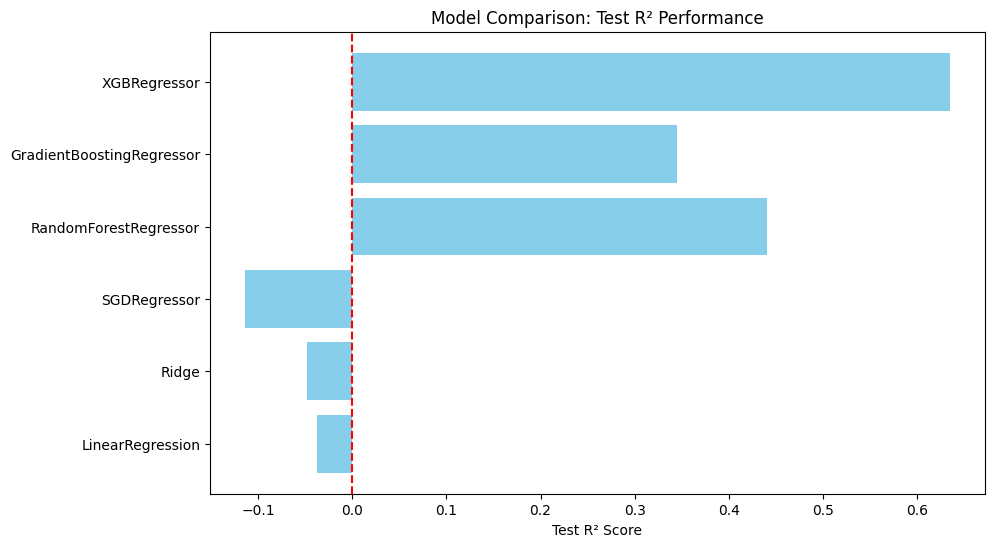

In [ ]:
import matplotlib.pyplot as plt

# Visualize
model_names = [r['model'] for r in results]
test_r2_scores = [float(r['test_r2']) for r in results]

plt.figure(figsize=(10, 6))
plt.barh(model_names, test_r2_scores, color='skyblue')
plt.xlabel('Test R² Score')
plt.title('Model Comparison: Test R² Performance')
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [ ]:
import joblib
# 1. Export the fitted model from the dictionary
best_xgb = models["XGBRegressor"]
joblib.dump(best_xgb, 'xgb_inflation_model.pkl')
# 2. Export the scalers
joblib.dump(year_scaler, 'year_scaler.pkl')
joblib.dump(feature_scaler, 'feature_scaler.pkl')
print("All 3 files saved")

All 3 files saved
